In [83]:
import pandas as pd
import torch
import numpy as np
import networkx as nx
from scipy.spatial.distance import euclidean
import torch
from sklearn.model_selection import train_test_split
import hyperparameters as hp
import random
import matplotlib.pyplot as plt

In [84]:
path = hp.FLOWDATA_PATH

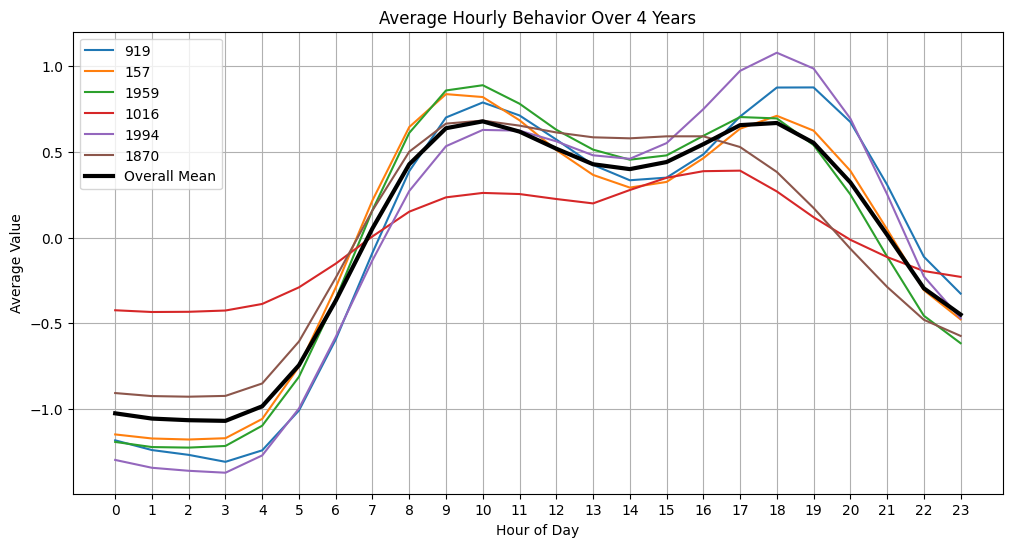

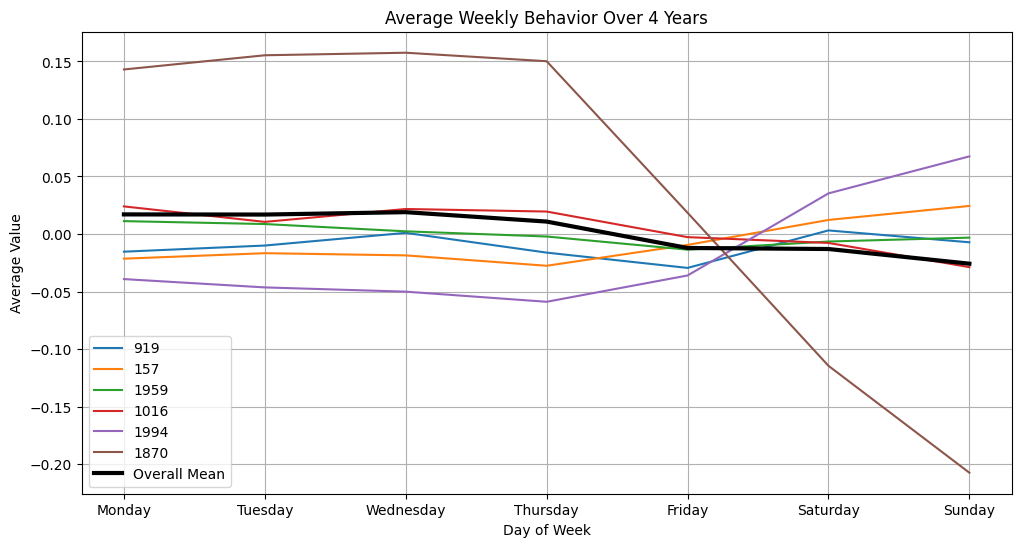

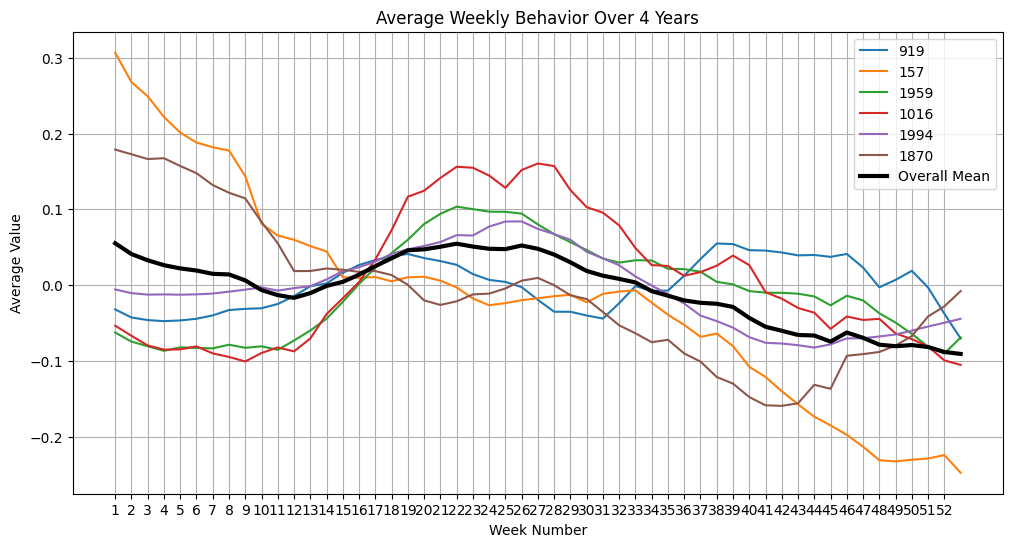

In [99]:
def print_avg_behaviour_graph(path, strata = 'season', window = 3):
    df = pd.read_csv(path, index_col=0)
    df.index = pd.to_datetime(df.index, format='%d/%m/%Y %H:%M')

    df = df.drop(columns=['1615']) 

    df = (df - df.mean()) / df.std()


    if strata == 'season':
        df['category'] = df.index.isocalendar().week
        xlabel="Week Number"
        title="Average Weekly Behavior Over 4 Years"
    elif strata == 'day':
        df['category'] = df.index.day_name()
        xlabel="Day of Week"
        title="Average Weekly Behavior Over 4 Years"
    elif strata == 'time of day':
        df['category'] = df.index.hour
        xlabel = "Hour of Day"
        title = "Average Hourly Behavior Over 4 Years"


    df_avg = df.groupby('category').mean()

    if strata == 'day':
        days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
        df_avg = weekly_avg.reindex(days_order)

    df_avg = df_avg.rolling(window=window, min_periods=1, center=True).mean()
    

    plt.figure(figsize=(12,6))
    for col in df_avg.columns:
        plt.plot(df_avg.index, df_avg[col], label=col)

    
    plt.plot(df_avg.index, df_avg.mean(axis=1), color='black', linewidth=3, label='Overall Mean')

    if strata == 'time of day':
        plt.xticks(range(0, 24))
    if strata == 'season':
        plt.xticks(range(1, 53))

    plt.xlabel(xlabel)
    plt.ylabel("Average Value")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

print_avg_behaviour_graph(path, window = 4, strata='time of day')
print_avg_behaviour_graph(path, window = 4, strata='day')
print_avg_behaviour_graph(path, window = 15, strata='season')